# From serial sections to a volume, and reading Stereo-seq

Two things omicverse could not do before, both asked for in
[issue #760](https://github.com/omicverse/omicverse/issues/760).

**Geometry.** `pySTAligner` and `CAST` align *expression* and hand back a shared
embedding. An embedding cannot be sliced or measured in microns, because it has no
common coordinate frame — and a coordinate frame is exactly what a 3-D
reconstruction needs. `ov.space.geom` supplies it.

**Stereo-seq.** `ov.io.spatial` read Visium, Visium HD, Xenium, CosMx and Atera.
The whole BGI ecosystem was reachable only by going through Stereopy first.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
import scanpy as sc
import squidpy as sq
import omicverse as ov

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Checking the aligner against an answer we know

Serial sections arrive rotated and shifted by however the tissue landed on the
slide, and there is no ground truth to check a reconstruction against — a wrong
alignment still produces a tidy-looking volume.

So before trusting it on real sections, give it a problem whose answer is known:
take one real Visium slide, apply rotations and translations we choose, and ask
the aligner to undo them. The tissue and its expression are real; the transform is
the thing being measured.

In [3]:
slide = sq.datasets.visium_hne_adata()
sc.pp.subsample(slide, n_obs=800, random_state=0)
sc.pp.normalize_total(slide, target_sum=1e4)
sc.pp.log1p(slide)
print(f"{slide.n_obs} spots from a real mouse-brain Visium section")

800 spots from a real mouse-brain Visium section


In [4]:
def turn(adata, degrees, shift):
    t = np.deg2rad(degrees)
    rot = np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])
    xy = np.asarray(adata.obsm['spatial'], dtype=float)[:, :2]
    out = adata.copy()
    out.obsm['spatial'] = (xy - xy.mean(0)) @ rot + xy.mean(0) + np.asarray(shift)
    return out

In [5]:
imposed = [(0, (0, 0)), (17, (120, -80)), (-31, (-200, 150)), (48, (60, 300))]
sections = [turn(slide, d, s) for d, s in imposed]
truth = np.asarray(slide.obsm['spatial'], dtype=float)[:, :2]
span = float(np.linalg.norm(truth.max(0) - truth.min(0)))
print(f"4 sections, rotations {[d for d, _ in imposed]} deg, tissue {span:.0f} px across")

4 sections, rotations [0, 17, -31, 48] deg, tissue 10722 px across


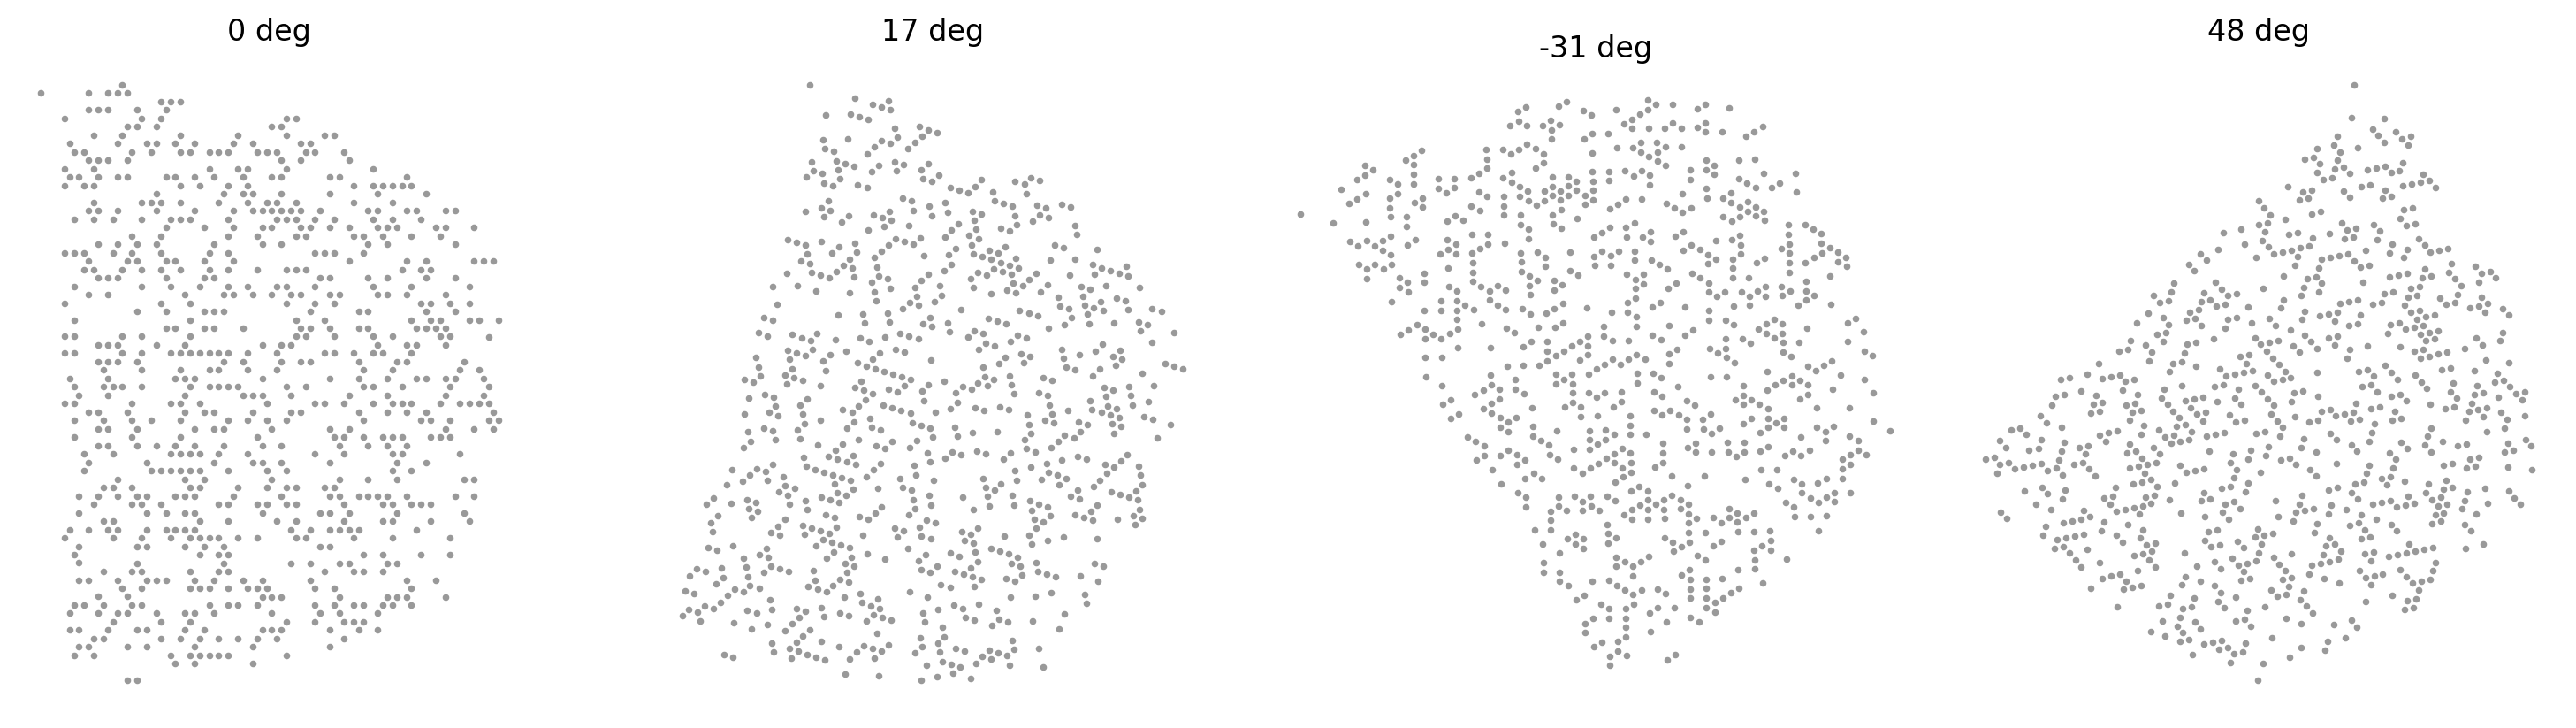

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
for ax, s, (d, _) in zip(axes, sections, imposed):
    xy = s.obsm['spatial']
    ax.scatter(xy[:, 0], xy[:, 1], s=3, c='0.6')
    ax.set_title(f'{d} deg'); ax.set_aspect('equal'); ax.axis('off')
plt.show()

`align` walks outwards from the reference section, aligning each to its neighbour's
*already aligned* coordinates so the transforms compose along the chain. The
default solves the fused Gromov-Wasserstein problem PASTE is built on — match
spots using both expression similarity and each slice's internal geometry, then
read a rigid transform off the coupling.

In [7]:
aligned = ov.space.geom.align(sections, method='fgw', alpha=0.1)
frame = aligned[0].obsm['spatial_aligned']
errors = [float(np.abs(s.obsm['spatial_aligned'] - frame).max()) for s in aligned]
print("max residual per section, in pixels:")
for (d, _), e in zip(imposed, errors):
    print(f"  {d:>4} deg -> {e:.2e}")

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


max residual per section, in pixels:
     0 deg -> 0.00e+00
    17 deg -> 5.46e-12
   -31 deg -> 3.64e-12
    48 deg -> 7.73e-12


Machine precision. The imposed rotations come back exactly, including for the
sections at the end of the chain — which is the part that actually tests the
implementation, because an aligner that only carries translation forward looks
correct on section 1 and drifts thereafter.

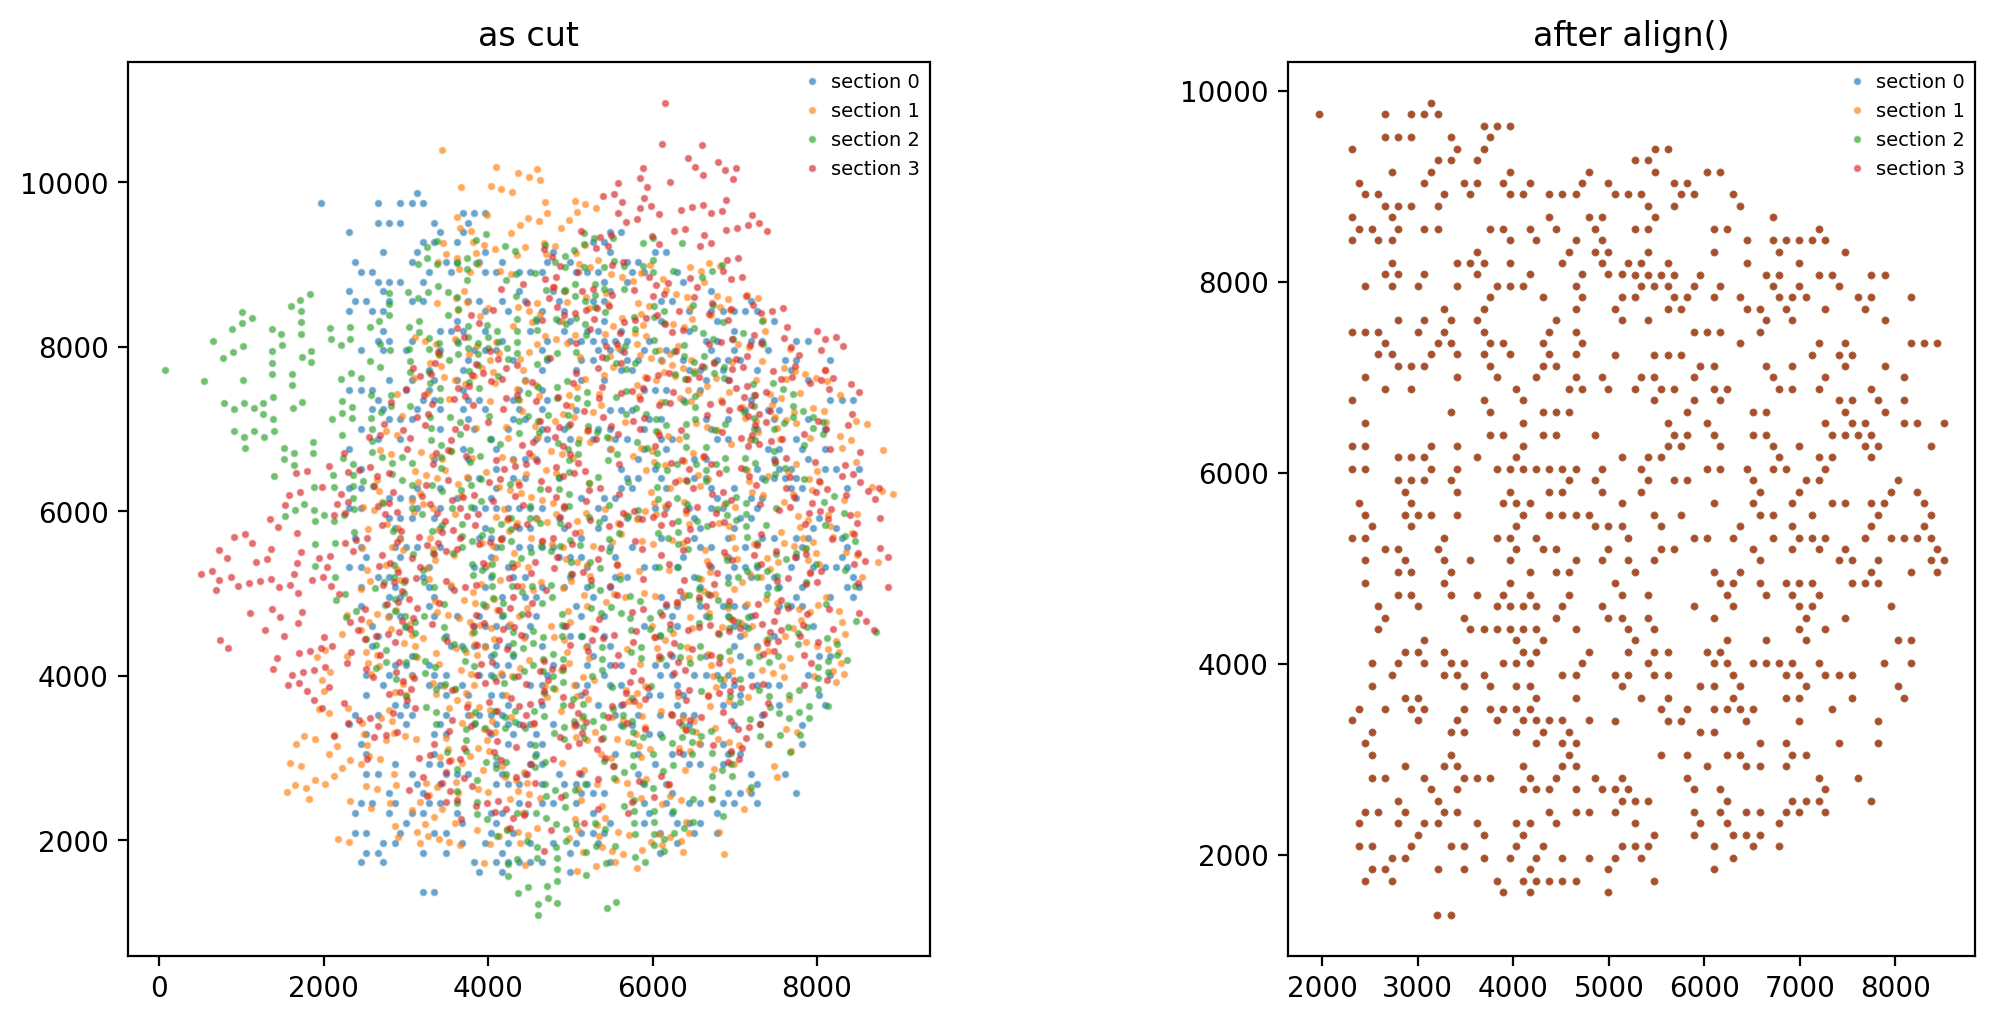

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, key, title in zip(axes, ['spatial', 'spatial_aligned'],
                          ['as cut', 'after align()']):
    for i, s in enumerate(aligned):
        xy = s.obsm[key]
        ax.scatter(xy[:, 0], xy[:, 1], s=3, alpha=0.5, label=f'section {i}')
    ax.set_title(title); ax.set_aspect('equal'); ax.legend(fontsize=7)
plt.show()

### Which method, and when

`method='icp'` matches nearest points and ignores expression. It is faster, but it
converges to whichever local minimum it starts near, and how far it can be pushed
depends on how much the shape of the tissue constrains the fit — it is not one
number.

In [9]:
rows = []
for degrees in (10, 30, 60, 90, 150):
    turned = turn(slide, degrees, (0, 0))
    entry = {'rotation': f'{degrees} deg'}
    for method in ('icp', 'fgw'):
        moved, _ = ov.space.geom.align_pairwise(turned, slide, method=method)
        entry[method] = f"{np.abs(moved - truth).max():.2e}"
    rows.append(entry)
pd.DataFrame(rows).set_index('rotation')

,icp,fgw
rotation,,
10 deg,5.91e-12,3.64e-12
30 deg,1.09e-11,4.55e-12
60 deg,1.64e-11,4.55e-12
90 deg,7.92e+03,8.73e-11
150 deg,8.75e+03,1.09e-11


On this slide ICP holds to about 60 degrees and then fails outright. Measured
elsewhere: on a uniform random cloud it fails from 20 degrees, and on a *regular
lattice* it fails at 10 — worst where the geometry looks most orderly, because the
lattice's own six-fold symmetry makes nearest-point correspondences genuinely
ambiguous. FGW was exact in all three cases at every angle tested up to 170
degrees, which is why it is the default.

## Stacking into a volume

`z_spacing` is the physical distance between consecutive sections, in the same
units as the in-plane coordinates. Getting it wrong does not fail — it silently
stretches or squashes the volume, and every distance measured through the stack
afterwards is wrong by that factor. Pass `z_values` when the sections were not cut
at a constant interval.

In [10]:
volume = ov.space.geom.stack(aligned, z_spacing=10.0)
print(volume)

AnnData object with n_obs × n_vars = 3200 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'section'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'geom_stack'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_aligned', 'spatial_3d'
    varm: 'PCs'


In [11]:
xyz = volume.obsm['spatial_3d']
print(f"3-D coordinates {xyz.shape}; z levels {sorted(set(xyz[:, 2]))}")
print(f"sections recorded in obs: {list(volume.obs['section'].cat.categories)}")

3-D coordinates (3200, 3); z levels [np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0)]
sections recorded in obs: ['0', '1', '2', '3']


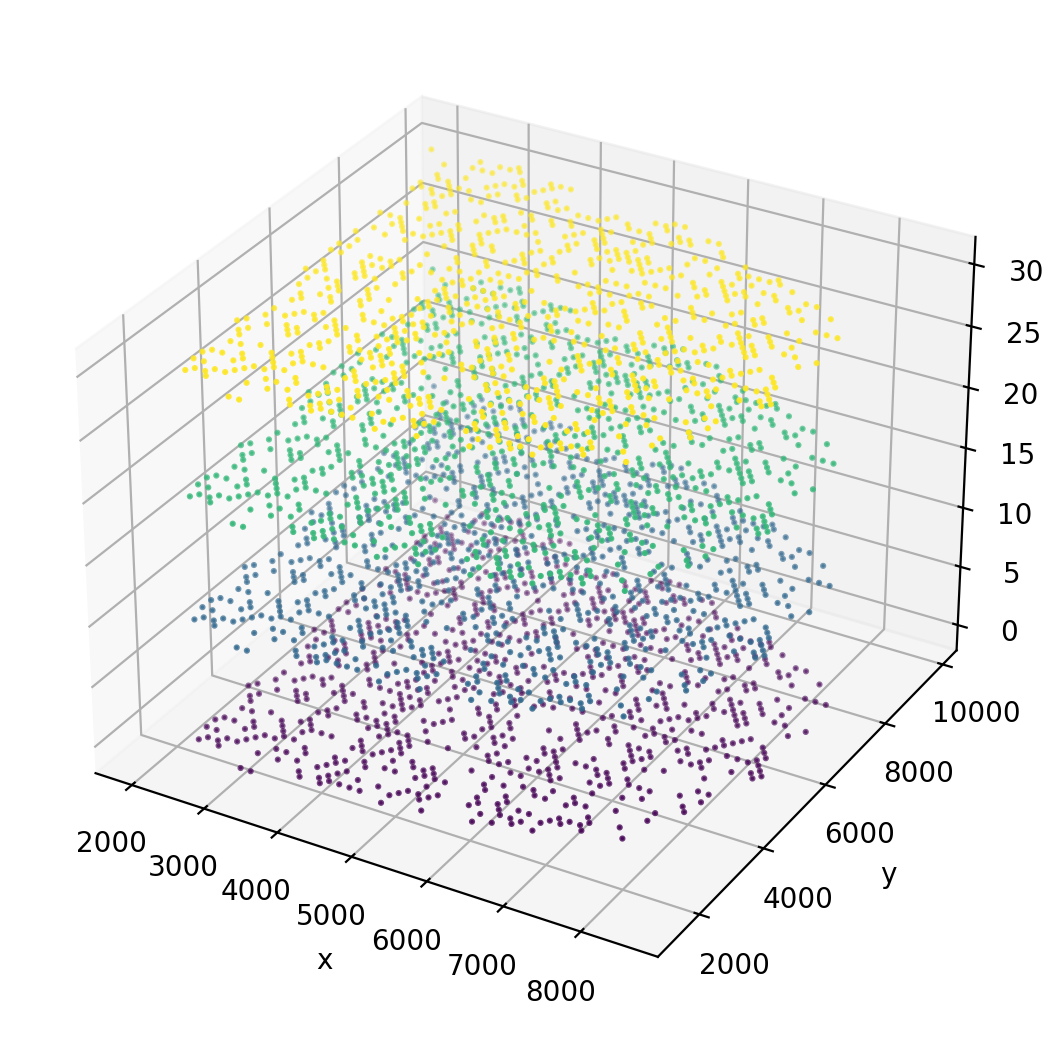

In [12]:
fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(projection='3d')
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=1.5,
           c=volume.obs['section'].cat.codes, cmap='viridis')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.show()

## Filling the gap between sections

Serial sectioning throws away everything between the cuts. `interpolate` fills a
slab of that gap by blending each spot of the lower section with its nearest
neighbours in the upper one.

It is interpolation, not measurement — a plausible reading of what lies between two
observations, not data. It is useful for rendering a continuous volume, and as a
check on the alignment: a bad alignment produces obvious nonsense here.

In [13]:
virtual = ov.space.geom.interpolate(aligned[0], aligned[1], fraction=0.5)
print(f"virtual section: {virtual.shape}, flagged "
      f"uns['geom_interpolated'] = {virtual.uns['geom_interpolated']}")

virtual section: (800, 18078), flagged uns['geom_interpolated'] = True


## Reading Stereo-seq

A GEM file is one row per (gene, x, y) with a count, on a 500 nm grid. That
resolution is below one cell, so the first real decision in every Stereo-seq
analysis is the bin size — and it changes every result after it.

There is no small public GEM to ship with a tutorial, so this section writes one in
the format BGI produces and reads it back. The file layout, the header, the binning
arithmetic and the count conservation are all exactly what a real GEM exercises;
only the counts themselves are stand-ins.

In [14]:
import gzip, tempfile, os
rng = np.random.default_rng(0)
rows = 60000
gem = pd.DataFrame({'geneID': rng.choice([f'Gene{i}' for i in range(200)], rows),
                    'x': rng.integers(0, 2000, rows),
                    'y': rng.integers(0, 2000, rows),
                    'MIDCount': rng.integers(1, 5, rows)})

In [15]:
path = os.path.join(tempfile.mkdtemp(), 'demo.gem.gz')
with gzip.open(path, 'wt') as handle:
    handle.write('#FileFormat=GEMv0.1\n#StereoChip=SS200000\n')
    gem.to_csv(handle, sep='\t', index=False)
print(f"wrote a {rows:,}-row GEM over a 2000 x 2000 spot field")

wrote a 60,000-row GEM over a 2000 x 2000 spot field


In [16]:
fine = ov.io.spatial.read_stereoseq(path, bin_size=50)
print(fine)

AnnData object with n_obs × n_vars = 1600 × 200
    uns: 'stereoseq'
    obsm: 'spatial'


In [17]:
meta = fine.uns['stereoseq']
print(f"bin {meta['bin_size']} spots = {meta['bin_size_um']} um square")
print(f"counts conserved: {int(fine.X.sum()):,} read vs {int(gem.MIDCount.sum()):,} in the file")
print(f"chip from the header: {meta['header']['StereoChip']}")

bin 50 spots = 25.0 um square
counts conserved: 150,159 read vs 150,159 in the file
chip from the header: SS200000


Bin size is worth sweeping, not guessing. Bins much smaller than a cell give sparse
noisy profiles; bins much larger mix cell types together and no deconvolution will
fully undo that.

In [18]:
sweep = []
for size in (20, 50, 100, 200):
    binned = ov.io.spatial.read_stereoseq(path, bin_size=size)
    density = float((binned.X > 0).sum() / np.prod(binned.shape))
    sweep.append({'bin (spots)': size, 'um': size * 0.5, 'bins': binned.n_obs,
                  'genes seen per bin': f"{(binned.X > 0).sum(axis=1).mean():.1f}",
                  'matrix density': f"{density:.3f}"})
pd.DataFrame(sweep).set_index('bin (spots)')

,um,bins,genes seen per bin,matrix density
bin (spots),,,,
20,10.0,9984,5.9,0.030
50,25.0,1600,34.2,0.171
100,50.0,400,105.6,0.528
200,100.0,100,190.0,0.950


Re-reading the file to try another bin size is slow. `bin_stereoseq` coarsens an
object already in memory, and refuses a size the existing bins do not nest into
rather than silently splitting counts across boundaries.

In [19]:
coarse = ov.io.spatial.bin_stereoseq(fine, bin_size=100)
direct = ov.io.spatial.read_stereoseq(path, bin_size=100)
print(f"rebinned  {coarse.shape}, {int(coarse.X.sum()):,} counts")
print(f"re-read   {direct.shape}, {int(direct.X.sum()):,} counts")
print(f"identical: {coarse.shape == direct.shape and int(coarse.X.sum()) == int(direct.X.sum())}")

rebinned  (400, 200), 150,159 counts
re-read   (400, 200), 150,159 counts
identical: True


In [20]:
try:
    ov.io.spatial.bin_stereoseq(fine, bin_size=75)
except ValueError as err:
    print(f"refused, correctly: {err}")

refused, correctly: bin_size 75 is not a whole multiple of the current 50; the bins would not nest and counts would be split across boundaries.


The binned object is an ordinary AnnData with `obsm['spatial']`, so everything else
in `ov.space` applies to it — including the arrangement statistics and niche
analysis in [the arrangement tutorial](t_spatial_arrangement.ipynb). Use
`coord_type='grid'` when building the graph: Stereo-seq bins sit on a square
lattice, and plain k-NN will reach across gaps at the tissue edge.

In [21]:
ov.space.spatial_neighbors(fine, n_neighs=4, coord_type='grid')
degree = np.asarray((fine.obsp['spatial_connectivities'] > 0).sum(axis=1)).ravel()
print(f"{fine.obsp['spatial_connectivities'].nnz:,} edges, degree {degree.min()}-{degree.max()}")

Spatial neighbors: 1600 cells, 6058 connections (avg 3.8 neighbors/cell).
Stored in adata.obsp['spatial_connectivities'] and adata.obsp['spatial_distances'].
6,058 edges, degree 2-4


## What this does and does not give you

`align` recovers a rigid transform — rotation and translation. Real serial sections
also stretch, tear and fold, and none of that is corrected here; methods that model
it exist ([ST-GEARS](https://www.nature.com/articles/s41467-024-51935-0) solves
elastic fields, [STalign](https://www.nature.com/articles/s41467-023-43915-7) uses
diffeomorphic metric mapping) and `method=` is where they would attach.

`method='paste'` defers to the [PASTE](https://pubmed.ncbi.nlm.nih.gov/37553263/)
package when it is installed. The default solves the same problem over POT, so the
default path needs nothing beyond what omicverse already brings.

Section order is the physical cutting order. Shuffling it produces a volume that
looks smooth and is wrong, and nothing in the code can detect that for you.